### RaschPy pseudo_halo (item_stretch) MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 12 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

The `pseudo_halo` parameterisation is the item-facet analogue of `centrality` (see the companion notebook): it restricts the fully-free `items` parameterisation (a separate severity per facet x item combination) down to two parameters per facet element ('rater' henceforth for simplicity, although the model may be used for any additional facet): a global shift `lambda_r` and an item-difficulty stretch `omega_r`. `omega_r < 1` compresses the spread of reference item locations toward zero for that rater – items look more similar in difficulty to that rater than they really are, the halo signature (ironing out real item-difficulty differences). `omega_r > 1` exaggerates real item-difficulty differences instead. `omega_r = 1` is neutral and collapses to the `global` model.

The model is called `pseudo_halo` because a compression, with a flatter item location profile, increases the likelihood of a flat score profile in the response data, this is different from classic halo effect's usual mechanism: while classic halo effect involves elevated local item interdependence (LID), which can be seen in the rater's residual correlations since the rater's overall impression of a person affects scores across items, `pseudo halo` does not require LID. Confirming or ruling out true local-dependence-based halo needs pairing `omega_r` with the residual-correlation diagnostics produced by `item_res_corr_analysis`, run on a per-rater basis to identify elevated LID from a given rater. The model also has a descriptive alias, `item_stretch` in parallel to the `items` model, of which it is a restricted case (see also `threshold_stretch` for the `centrality` model, and `bistretch` for the combined model, analogous to the `bivector` model).

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import pandas as pd
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if the data is disconnected — i.e. there is no chain of persons and items linking every item to every other, the resulting item locations are not on a common scale, even though `calibrate()` will still run without error. Here we build a small, deliberately disconnected data set as an example: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Items(no_of_items=8, no_of_persons=40, no_of_facet_elements=4, max_score=5, seed=1234)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:476: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_97150/2780567350.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': [],
 'strongly_connected': False}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=999` makes the simulation fully reproducible – rerunning this notebook will always generate the same data set. 12 items, 8 raters, 200 persons, no missing data. We simulate under the dedicated `MFRM_Sim_PseudoHalo` simulator, which generates data with *true* `lambda_r`/`omega_r` stretch structure directly, for a genuine parameter recovery check further down.

In [4]:
sim = rp.MFRM_Sim_PseudoHalo(no_of_items=12, no_of_persons=200, no_of_facet_elements=8, max_score=5, missing=0, seed=999)
sim.responses.to_csv('mfrm_pseudo_halo_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_pseudo_halo_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     1.0     3.0     3.0     2.0     3.0     2.0     4.0   
        Person_2     1.0     1.0     3.0     1.0     2.0     3.0     3.0   

                  Item_8  Item_9  Item_10  Item_11  Item_12  
Rater   Person                                               
Rater_1 Person_1     3.0     3.0      3.0      3.0      2.0  
        Person_2     3.0     3.0      3.0      3.0      1.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater,Person,,,,,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the pseudo_halo parameterisation. This first runs the full `items` PAIR estimation internally (a separate severity per rater x item combination), then closed-form derives each rater's `lambda_r`/`omega_r` from it – no new estimation. The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_pseudo_halo()

CPU times: user 29.7 ms, sys: 10.2 ms, total: 39.9 ms
Wall time: 45 ms


`lambda_r/omega_r` are recovered per rater via a robust regression of that rater's raw free-model deviation values against the reference item/threshold values, controlled by `regression='huber'` (default) or `regression='theil-sen'`. `'huber'` was the most accurate of several methods tested empirically (see the manual for the comparison); `'theil-sen'` (median of pairwise slopes, fully closed-form) is a close second, with no iterative fit to converge. If `'huber'` fails to converge for a given rater, that rater automatically falls back to `'theil-sen'` with a `UserWarning` naming it – the rest are unaffected:

In [10]:
mfrm_theilsen = rp.MFRM(sim)
mfrm_theilsen.calibrate_pseudo_halo(regression='theil-sen')

As already noted, `pseudo_halo` has an alias, `item_stretch`. `item_stretch` works anywhere a model name is accepted – both as the `model=`/`models=` value and as a method-name suffix – and results still land under the same `_pseudo_halo`-suffixed attribute names regardless of which spelling calibrated them:

In [11]:
mfrm_alias = rp.MFRM(sim)
mfrm_alias.calibrate_item_stretch()   # identical to calibrate_pseudo_halo()
(mfrm_alias.lambda_pseudo_halo == mfrm.lambda_pseudo_halo).all(), (mfrm_alias.omega_pseudo_halo == mfrm.omega_pseudo_halo).all()

(np.True_, np.True_)

Check the item location estimates

In [12]:
mfrm.items

Item_1     0.946165
Item_2     0.276447
Item_3    -0.413381
Item_4     0.726436
Item_5     0.862625
Item_6    -0.198654
Item_7    -0.170377
Item_8    -1.031121
Item_9    -0.828731
Item_10   -0.167606
Item_11   -0.902873
Item_12    0.901069
dtype: float64

Since this is simulated data, we know the true generating item locations (`mfrm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) – the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

In [13]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:               {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} Regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(float(np.sqrt(np.mean((x - y) ** 2))), 3)}')

Generate a table of item statistics (and check run time), and save to file

In [14]:
%%time
mfrm.item_stats_df_pseudo_halo(full=True)
mfrm.item_stats_pseudo_halo.to_csv('mfrm_pseudo_halo_item_stats.csv')

CPU times: user 9.98 s, sys: 273 ms, total: 10.3 s
Wall time: 10.3 s


Check the item statistics table

In [15]:
mfrm.item_stats_pseudo_halo

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,0.946,0.042,0.870,1.032,1600,0.426,0.961,-1.101,0.954,-1.299,0.610,0.606
Item_2,0.276,0.043,0.201,0.373,1600,0.498,0.953,-1.351,0.965,-0.978,0.635,0.618
Item_3,-0.413,0.045,-0.504,-0.328,1600,0.565,0.982,-0.492,0.991,-0.252,0.623,0.613
Item_4,0.726,0.042,0.650,0.812,1600,0.454,0.918,-2.369,0.916,-2.436,0.630,0.611
Item_5,0.863,0.045,0.773,0.952,1600,0.437,0.982,-0.492,0.974,-0.727,0.618,0.608
Item_6,-0.199,0.044,-0.285,-0.117,1600,0.541,0.929,-2.054,0.931,-2.001,0.657,0.616
Item_7,-0.170,0.043,-0.257,-0.094,1600,0.540,0.970,-0.847,0.977,-0.637,0.630,0.616
Item_8,-1.031,0.046,-1.122,-0.941,1600,0.616,0.970,-0.836,0.969,-0.880,0.626,0.603
Item_9,-0.829,0.046,-0.914,-0.744,1600,0.599,0.971,-0.816,0.964,-1.031,0.592,0.607
Item_10,-0.168,0.041,-0.250,-0.087,1600,0.542,1.002,0.056,0.989,-0.307,0.607,0.616


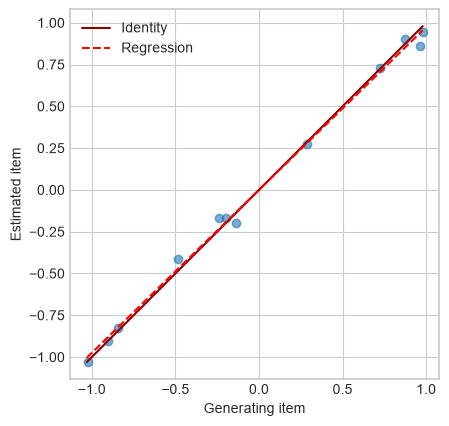

item Pearson correlation:               0.998
item SD ratio (estimated / generating): 0.977
item Regression coefficient:            0.975
item RMSE:                              0.048


In [16]:
recovery_plot(mfrm.generating.items, mfrm.items, 'item', 'my_mfrm_pseudo_halo_item_recovery.png')

Generate a table of threshold statistics (and check run time), and save to file

In [17]:
%%time
mfrm.threshold_stats_df_pseudo_halo(full=True)
mfrm.threshold_stats_pseudo_halo.to_csv('mfrm_pseudo_halo_threshold_stats.csv')

CPU times: user 97.8 ms, sys: 2.7 ms, total: 101 ms
Wall time: 100 ms


Check the threshold statistics table

In [18]:
mfrm.threshold_stats_pseudo_halo

,Estimate,SE,2.5%,97.5%,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Threshold 1,-4.091,0.065,-4.170,-3.914,0.879,-4.145,0.838,-2.901,1.113,0.395,0.393
Threshold 2,-1.451,0.043,-1.531,-1.362,0.979,-1.817,0.975,-1.393,1.053,0.622,0.586
Threshold 3,-1.259,0.032,-1.319,-1.194,0.993,-0.620,0.970,-1.297,1.015,0.768,0.740
Threshold 4,2.312,0.038,2.225,2.375,0.974,-1.979,0.936,-2.447,1.035,0.727,0.702
Threshold 5,4.489,0.076,4.305,4.595,0.945,-1.178,1.000,0.026,1.028,0.215,0.206


And the same recovery check for thresholds, against `mfrm.generating.thresholds`:

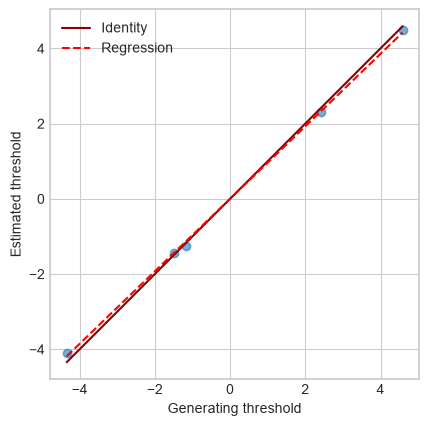

threshold Pearson correlation:               1.0
threshold SD ratio (estimated / generating): 0.964
threshold Regression coefficient:            0.964
threshold RMSE:                              0.141


In [19]:
recovery_plot(mfrm.generating.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_pseudo_halo_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file

In [20]:
%%time
mfrm.rater_stats_df_pseudo_halo()
mfrm.rater_stats_pseudo_halo.to_csv('mfrm_pseudo_halo_rater_stats.csv')
mfrm.rater_stats_pseudo_halo_full_vector.to_csv('mfrm_pseudo_halo_rater_stats_full_vector.csv')

CPU times: user 53.3 ms, sys: 1.57 ms, total: 54.8 ms
Wall time: 55 ms


Check the rater statistics table

In [21]:
mfrm.rater_stats_pseudo_halo

lambda           omega        Overall statistics                   
        Estimate     SE Estimate     SE              Count Infit MS Outfit MS
Rater_1    0.604  0.037    1.449  0.057             2400.0    0.941     0.944
Rater_2   -0.908  0.041    0.515  0.062             2400.0    0.965     0.975
Rater_3    0.435  0.040    1.063  0.053             2400.0    0.979     0.973
Rater_4    0.611  0.039    1.073  0.054             2400.0    0.974     0.980
Rater_5   -0.890  0.041    1.090  0.061             2400.0    0.950     0.954
Rater_6    0.972  0.040    1.161  0.059             2400.0    0.941     0.948
Rater_7   -1.028  0.041    0.965  0.063             2400.0    0.936     0.918
Rater_8    0.203  0.039    0.722  0.054             2400.0    0.945     0.950

`self.rater_stats_pseudo_halo` (above) is the model's own raw shift/stretch parameters (`lambda`, `omega`), each with its own bootstrap SE. The same call also stores the reconstructed full severity vector separately – what this table showed before this parameterisation had its own dedicated columns:

In [22]:
mfrm.rater_stats_pseudo_halo_full_vector

Item_1          Item_2          Item_3          Item_4         \
        Estimate     SE Estimate     SE Estimate     SE Estimate     SE   
Rater_1    1.029  0.068    0.728  0.042    0.418  0.049    0.930  0.057   
Rater_2   -1.367  0.078   -1.042  0.050   -0.708  0.053   -1.260  0.066   
Rater_3    0.494  0.060    0.452  0.041    0.409  0.048    0.480  0.052   
Rater_4    0.680  0.058    0.631  0.039    0.581  0.048    0.664  0.050   
Rater_5   -0.805  0.074   -0.865  0.047   -0.927  0.047   -0.825  0.063   
Rater_6    1.125  0.070    1.016  0.044    0.905  0.048    1.089  0.060   
Rater_7   -1.061  0.075   -1.037  0.046   -1.013  0.047   -1.053  0.064   
Rater_8   -0.061  0.062    0.126  0.042    0.318  0.048    0.001  0.054   

          Item_5         ... Item_9  Item_10         Item_11         Item_12  \
        Estimate     SE  ...     SE Estimate     SE Estimate     SE Estimate   
Rater_1    0.991  0.063  ...  0.063    0.528  0.044    0.198  0.068    1.008   
Rater_2   -1.326  0.072  ...  0.067   -0.827  0.048   -0.470  0.066   -1.345   
Rater_3    0.489  0.056  ...  0.063    0.424  0.042    0.378  0.066    0.491   
Rater_4    0.674  0.056  ...  0.065    0.599  0.042    0.545  0.068    0.676   
Rater_5   -0.812  0.069  ...  0.063   -0.905  0.042   -0.971  0.066   -0.809   
Rater_6    1.111  0.066  ...  0.063    0.945  0.042    0.826  0.067    1.117   
Rater_7   -1.058  0.071  ...  0.064   -1.022  0.042   -0.996  0.068   -1.059   
Rater_8   -0.037  0.058  ...  0.063    0.250  0.044    0.454  0.067   -0.048   

               Overall statistics                     
            SE              Count Infit MS Outfit MS  
Rater_1  0.066             2400.0    0.941     0.944  
Rater_2  0.069             2400.0    0.965     0.975  
Rater_3  0.058             2400.0    0.979     0.973  
Rater_4  0.056             2400.0    0.974     0.980  
Rater_5  0.071             2400.0    0.950     0.954  
Rater_6  0.067             2400.0    0.941     0.948  
Rater_7  0.073             2400.0    0.936     0.918  
Rater_8  0.059             2400.0    0.945     0.950  

[8 rows x 27 columns]

The two parameters `lambda_pseudo_halo` (severity shift) and `omega_pseudo_halo` (item-difficulty stretch) are the two parameters the model produces per rater – `mfrm.raters_pseudo_halo_full_vector` is just their reconstruction back into full (rater x item) form, for compatibility with all the same downstream fit-statistic and plotting machinery the other rater parameterisations use. The term `lambda` is used for the global severity since it is an additive parameter, as for instance in the `items` model, so `lambda` is consistent with the notation used elsewhere in the package. `omega` is used for the stretch parameter, following Jin & Wang (2018)'s own notation for a rater stretch factor – it is a multiplicative parameter rather than an additive one, so has a distinct Greek letter to distinguish it from the additive shift. A rater near `omega=1` is showing undistorted interpretations of item locations; well below 1 is the compressed-perception (pseudo-halo) signature; well above 1 is exaggerating real item location differences.

In [23]:
pd.DataFrame({'lambda (severity)': mfrm.lambda_pseudo_halo, 'omega (stretch)': mfrm.omega_pseudo_halo}).round(3)

,lambda (severity),omega (stretch)
Rater_1,0.604,1.449
Rater_2,-0.908,0.515
Rater_3,0.435,1.063
Rater_4,0.611,1.073
Rater_5,-0.890,1.090
Rater_6,0.972,1.161
Rater_7,-1.028,0.965
Rater_8,0.203,0.722


Pass `alias=True` to `rater_stats_df_pseudo_halo()` to relabel these columns with a human-readable name instead of the raw parameter name – `'Global'` for `lambda`, `'Item stretch'` for `omega` – purely cosmetic, the values themselves are unchanged:

In [24]:
mfrm.rater_stats_df_pseudo_halo(alias=True)
mfrm.rater_stats_pseudo_halo

Global        Item stretch        Overall statistics           \
        Estimate     SE     Estimate     SE              Count Infit MS   
Rater_1    0.604  0.037        1.449  0.057             2400.0    0.941   
Rater_2   -0.908  0.041        0.515  0.062             2400.0    0.965   
Rater_3    0.435  0.040        1.063  0.053             2400.0    0.979   
Rater_4    0.611  0.039        1.073  0.054             2400.0    0.974   
Rater_5   -0.890  0.041        1.090  0.061             2400.0    0.950   
Rater_6    0.972  0.040        1.161  0.059             2400.0    0.941   
Rater_7   -1.028  0.041        0.965  0.063             2400.0    0.936   
Rater_8    0.203  0.039        0.722  0.054             2400.0    0.945   

                   
        Outfit MS  
Rater_1     0.944  
Rater_2     0.975  
Rater_3     0.973  
Rater_4     0.980  
Rater_5     0.954  
Rater_6     0.948  
Rater_7     0.918  
Rater_8     0.950

To add an item-by-item divergence test comparing `pseudo_halo`'s vector reconstruction against `items`' own free per-item estimates to see which rater-item combinations, if any, show significant deviation from the uniform item stretching pattern and then inspect the per-rater flagged items and total count:

`divergence_test='wald'` references the test statistic against the standard normal distribution; `divergence_test='t'` uses a plain Student's t-distribution with `no_of_samples - 1` degrees of freedom instead, correcting (a little) for finite-bootstrap-sample uncertainty in the SE estimate itself. In practice `'t'` is only relevant when `no_of_samples` has deliberately been dropped for speed – at `no_of_samples=300` or more, `'wald'` and `'t'` give essentially the same p-values. With a larger `no_of_samples`, there is no reason to prefer `'t'` over `'wald'`.

Passing `full=True` gives two more ways to see which elements were flagged: one plain True/False column per item is added to the primary table itself, directly after the `'Flagged items'` count, for scanning flagged status across all elements at a glance – and `rater_stats_pseudo_halo_full_vector` receives a per-element `'Flagged'` column added to each item's own `Estimate`/`SE`/CI block displaying the same information alongside. The full `mfrm.rater_stats_pseudo_halo` is displayed here transposed using `.T` for visual convenience.

In [25]:
mfrm.rater_stats_df_pseudo_halo(full=True, divergence_test='wald', correction='bh')
mfrm.rater_stats_pseudo_halo.T

Rater_1 Rater_2 Rater_3 Rater_4 Rater_5 Rater_6  \
lambda             Estimate    0.604  -0.908   0.435   0.611   -0.89   0.972   
                   SE          0.036   0.045    0.04   0.038   0.042   0.042   
                   2.5%        0.537  -1.008   0.364   0.537  -0.975   0.907   
                   97.5%       0.676  -0.833   0.521   0.687  -0.816   1.064   
omega              Estimate    1.449   0.515   1.063   1.073    1.09   1.161   
                   SE          0.056   0.058   0.056   0.055   0.065   0.063   
                   2.5%        1.349   0.374   0.944   0.971   0.947    1.05   
                   97.5%       1.567   0.603   1.155   1.197     1.2   1.294   
Flagged items      Count         0.0     0.0     0.0     0.0     0.0     0.0   
Item_1             Flagged     False   False   False   False   False   False   
Item_2             Flagged     False   False   False   False   False   False   
Item_3             Flagged     False   False   False   False   False   False   
Item_4             Flagged     False   False   False   False   False   False   
Item_5             Flagged     False   False   False   False   False   False   
Item_6             Flagged     False   False   False   False   False   False   
Item_7             Flagged     False   False   False   False   False   False   
Item_8             Flagged     False   False   False   False   False   False   
Item_9             Flagged     False   False   False   False   False   False   
Item_10            Flagged     False   False   False   False   False   False   
Item_11            Flagged     False   False   False   False   False   False   
Item_12            Flagged     False   False   False   False   False   False   
Overall statistics Count      2400.0  2400.0  2400.0  2400.0  2400.0  2400.0   
                   Infit MS    0.941   0.965   0.979   0.974    0.95   0.941   
                   Infit Z    -2.022  -1.091  -0.702  -0.887   -1.61  -2.076   
                   Outfit MS   0.944   0.975   0.973    0.98   0.954   0.948   
                   Outfit Z   -1.803  -0.731  -0.846  -0.612  -1.421  -1.676   

                             Rater_7 Rater_8  
lambda             Estimate   -1.028   0.203  
                   SE           0.04   0.038  
                   2.5%       -1.107   0.122  
                   97.5%      -0.947   0.272  
omega              Estimate    0.965   0.722  
                   SE          0.064   0.055  
                   2.5%         0.85   0.604  
                   97.5%        1.11   0.818  
Flagged items      Count         0.0     0.0  
Item_1             Flagged     False   False  
Item_2             Flagged     False   False  
Item_3             Flagged     False   False  
Item_4             Flagged     False   False  
Item_5             Flagged     False   False  
Item_6             Flagged     False   False  
Item_7             Flagged     False   False  
Item_8             Flagged     False   False  
Item_9             Flagged     False   False  
Item_10            Flagged     False   False  
Item_11            Flagged     False   False  
Item_12            Flagged     False   False  
Overall statistics Count      2400.0  2400.0  
                   Infit MS    0.936   0.945  
                   Infit Z    -2.065  -1.854  
                   Outfit MS   0.918    0.95  
                   Outfit Z   -2.543   -1.55

And the same recovery check, comparing `mfrm.generating.lambda_`/`mfrm.generating.omega` with the recovered estimates, plotted separately since they're on different scales:

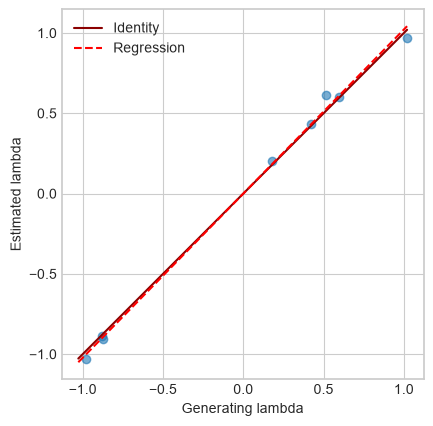

lambda Pearson correlation:               0.999
lambda SD ratio (estimated / generating): 1.023
lambda Regression coefficient:            1.022
lambda RMSE:                              0.043


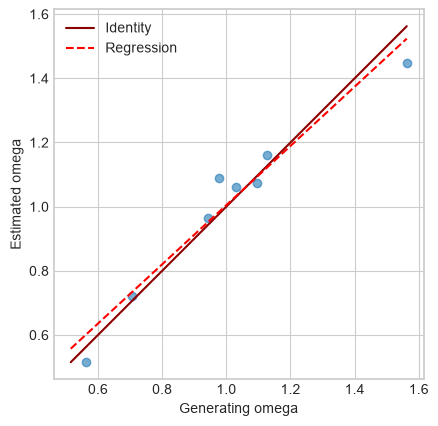

omega Pearson correlation:               0.975
omega SD ratio (estimated / generating): 0.946
omega Regression coefficient:            0.923
omega RMSE:                              0.063


In [26]:
recovery_plot(mfrm.generating.lambda_, mfrm.lambda_pseudo_halo, 'lambda', 'my_mfrm_pseudo_halo_lambda_recovery.png')
recovery_plot(mfrm.generating.omega, mfrm.omega_pseudo_halo, 'omega', 'my_mfrm_pseudo_halo_omega_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [27]:
%%time
mfrm.person_stats_df_pseudo_halo(full=True)
mfrm.person_stats_pseudo_halo.to_csv('mfrm_pseudo_halo_person_stats.csv')

CPU times: user 14.9 ms, sys: 1.72 ms, total: 16.7 ms
Wall time: 16.5 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [28]:
mfrm.person_stats_pseudo_halo.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Outfit MS,Infit Z,Outfit Z
Person_1,0.961,0.164,0.165,296,480,0.617,1.008,0.972,0.105,-0.107
Person_2,-0.716,0.140,0.138,223,480,0.465,0.980,0.981,-0.094,-0.070
Person_3,-3.134,0.151,0.148,95,480,0.198,0.961,0.957,-0.210,-0.244
Person_4,0.041,0.151,0.152,259,480,0.540,1.018,0.996,0.168,0.031
Person_5,0.620,0.160,0.155,283,480,0.590,0.945,0.854,-0.292,-0.831
Person_6,-0.908,0.138,0.134,213,480,0.444,0.952,0.988,-0.298,-0.028
Person_7,-0.289,0.146,0.134,244,480,0.508,0.848,0.823,-1.000,-1.080
Person_8,-0.983,0.137,0.136,209,480,0.435,0.982,1.073,-0.081,0.518
Person_9,0.801,0.162,0.171,290,480,0.604,1.115,1.062,0.734,0.410
Person_10,-1.953,0.134,0.132,155,480,0.323,0.963,0.968,-0.236,-0.188


And the same recovery check for person locations, against `mfrm.generating.persons`:

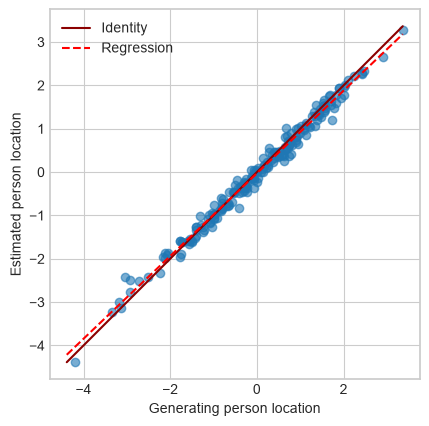

person location Pearson correlation:               0.994
person location SD ratio (estimated / generating): 0.96
person location Regression coefficient:            0.954
person location RMSE:                              0.156


In [29]:
recovery_plot(mfrm.generating.persons, mfrm.persons_pseudo_halo, 'person location', 'my_mfrm_pseudo_halo_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [30]:
%%time
mfrm.test_stats_df_pseudo_halo()
mfrm.test_stats_pseudo_halo.to_csv('mfrm_pseudo_halo_test_stats.csv')

CPU times: user 2.94 ms, sys: 607 μs, total: 3.55 ms
Wall time: 3.4 ms


Check the test statistics table

In [31]:
mfrm.test_stats_pseudo_halo

,Items,Persons
Mean,-0.000,-0.029
SD,0.732,1.278
Separation ratio,17.114,8.530
Strata,23.152,11.707
Reliability,0.997,0.986


Run a residual correlation analysis for items (and check run time), and save relevant output to file. This is the diagnostic to pair with `omega_pseudo_halo` for disentangling compressed-perception `pseudo_halo` from genuine local-dependence-based halo effect, as discussed at the top of this notebook.

In [32]:
%%time
mfrm.item_res_corr_analysis_pseudo_halo()
mfrm.item_residual_correlations_pseudo_halo.to_csv('mfrm_pseudo_halo_item_residual_correlations.csv')
mfrm.item_loadings_pseudo_halo.to_csv('mfrm_pseudo_halo_item_loadings.csv')

CPU times: user 7.91 ms, sys: 2.48 ms, total: 10.4 ms
Wall time: 14.7 ms


View the table of pairwise standard residual correlations (pairwise local item independence check)

In [33]:
round(mfrm.item_residual_correlations_pseudo_halo, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Item_1,1.000,-0.028,-0.017,-0.011,0.003,0.036,-0.043,-0.027,0.024,-0.015,-0.032,-0.039
Item_2,-0.028,1.000,-0.035,-0.060,-0.002,-0.003,-0.023,-0.026,0.005,-0.047,0.044,0.002
Item_3,-0.017,-0.035,1.000,0.005,-0.039,0.006,-0.021,-0.046,-0.005,-0.011,-0.007,-0.057
Item_4,-0.011,-0.060,0.005,1.000,-0.072,-0.044,-0.010,0.007,-0.029,0.005,-0.006,-0.007
Item_5,0.003,-0.002,-0.039,-0.072,1.000,-0.027,-0.019,0.034,0.030,0.004,-0.026,0.029
Item_6,0.036,-0.003,0.006,-0.044,-0.027,1.000,-0.006,-0.061,0.009,0.004,-0.055,-0.071
Item_7,-0.043,-0.023,-0.021,-0.010,-0.019,-0.006,1.000,0.045,-0.048,-0.000,-0.015,-0.025
Item_8,-0.027,-0.026,-0.046,0.007,0.034,-0.061,0.045,1.000,0.018,-0.006,0.026,-0.022
Item_9,0.024,0.005,-0.005,-0.029,0.030,0.009,-0.048,0.018,1.000,-0.002,0.007,-0.003
Item_10,-0.015,-0.047,-0.011,0.005,0.004,0.004,-0.000,-0.006,-0.002,1.000,-0.008,-0.022


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [34]:
round(mfrm.item_loadings_pseudo_halo['PC 1'], 3)

Item_1     0.127
Item_2    -0.050
Item_3     0.125
Item_4     0.011
Item_5    -0.083
Item_6     0.192
Item_7    -0.047
Item_8    -0.136
Item_9     0.015
Item_10    0.034
Item_11   -0.079
Item_12   -0.129
Name: PC 1, dtype: float64

Run a residual correlation analysis for raters (and check run time), and save relevant output to file

In [35]:
%%time
mfrm.rater_res_corr_analysis_pseudo_halo()
mfrm.rater_residual_correlations_pseudo_halo.to_csv('mfrm_pseudo_halo_rater_residual_correlations.csv')
mfrm.rater_loadings_pseudo_halo.to_csv('mfrm_pseudo_halo_rater_loadings.csv')

CPU times: user 13.3 ms, sys: 864 μs, total: 14.1 ms
Wall time: 14.2 ms


View the table of pairwise standard residual correlations (pairwise local rater independence check)

In [36]:
round(mfrm.rater_residual_correlations_pseudo_halo, 3)

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000,0.004,-0.015,-0.012,0.006,0.016,-0.011,-0.010
Rater_2,0.004,1.000,-0.025,0.015,-0.029,0.006,-0.002,0.018
Rater_3,-0.015,-0.025,1.000,-0.011,-0.023,-0.025,0.021,-0.028
Rater_4,-0.012,0.015,-0.011,1.000,-0.034,-0.034,-0.011,-0.036
Rater_5,0.006,-0.029,-0.023,-0.034,1.000,-0.034,0.000,-0.041
Rater_6,0.016,0.006,-0.025,-0.034,-0.034,1.000,-0.005,-0.013
Rater_7,-0.011,-0.002,0.021,-0.011,0.000,-0.005,1.000,-0.044
Rater_8,-0.010,0.018,-0.028,-0.036,-0.041,-0.013,-0.044,1.000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [37]:
round(mfrm.rater_loadings_pseudo_halo['PC 1'], 3)

Rater_1    0.035
Rater_2    0.142
Rater_3   -0.177
Rater_4   -0.015
Rater_5   -0.127
Rater_6    0.085
Rater_7   -0.186
Rater_8    0.245
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

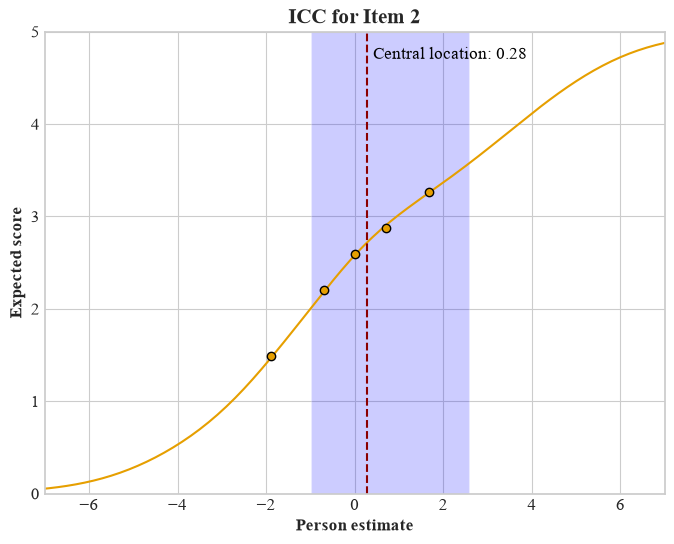

In [38]:
mfrm.icc_pseudo_halo('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-7, xmax=7, filename='my_mfrm_pseudo_halo_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

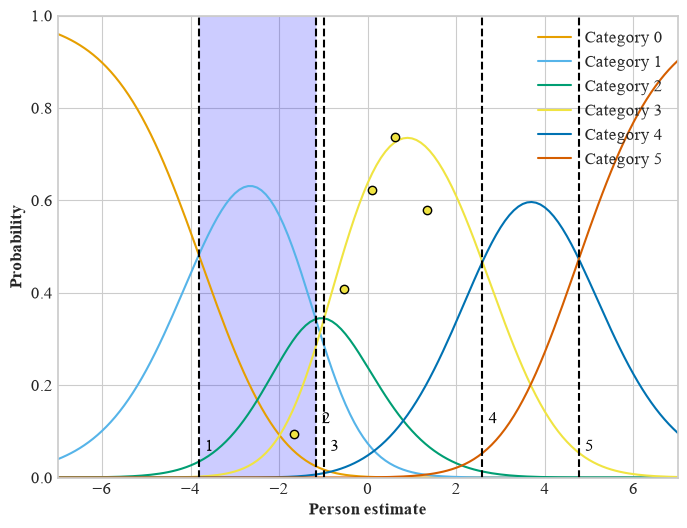

In [39]:
mfrm.crcs_pseudo_halo('Item_2', thresh_lines=True, obs=[3], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_pseudo_halo_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 3, category 1 highlighted and the thresholds marked

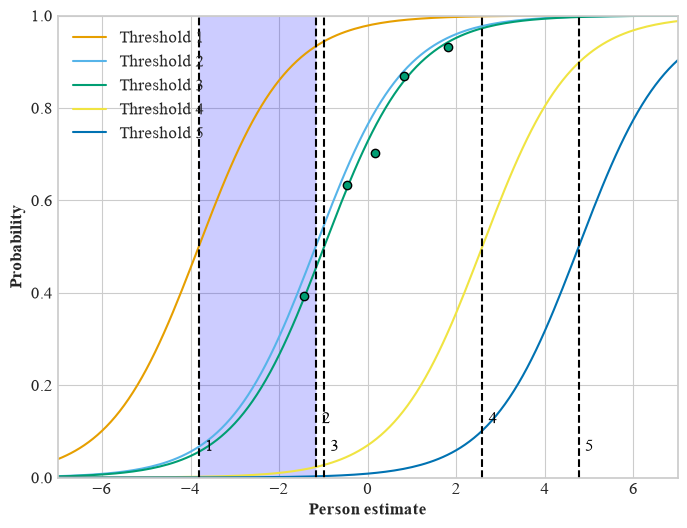

In [40]:
mfrm.threshold_ccs_pseudo_halo('Item_2', thresh_lines=True, obs=[3], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_pseudo_halo_threshold_ccs')

Produce an item information function curve for Item 2

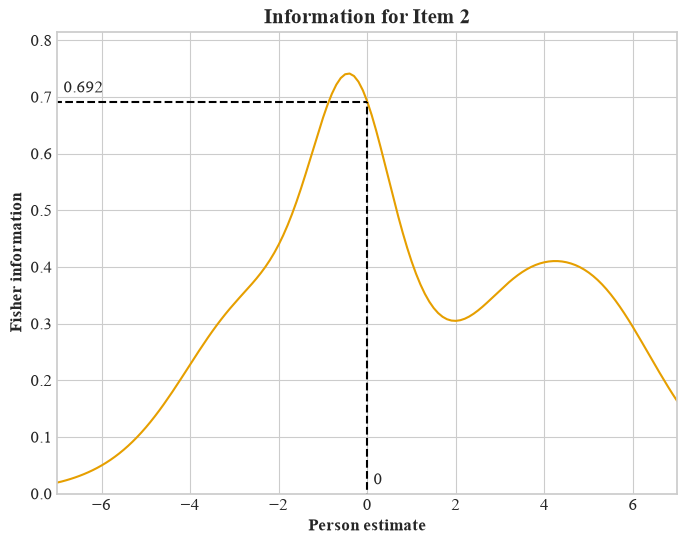

In [41]:
mfrm.iic_pseudo_halo('Item_2', point_info_lines=[0], point_info_labels=True,
                     title='Information for Item 2', xmin=-7, xmax=7, filename='my_mfrm_pseudo_halo_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 150 and 250 (aggregated across all raters) plotted.

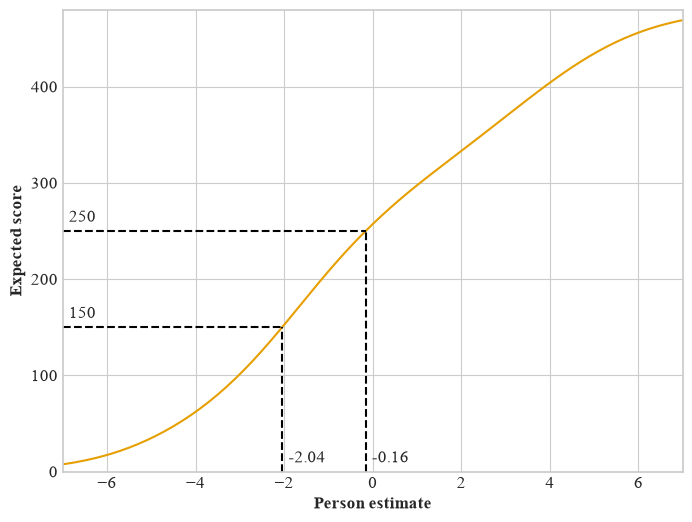

In [42]:
mfrm.tcc_pseudo_halo(score_lines=[150, 250], score_labels=True, xmin=-7, xmax=7, filename='my_mfrm_pseudo_halo_tcc')

Produce a test information curve

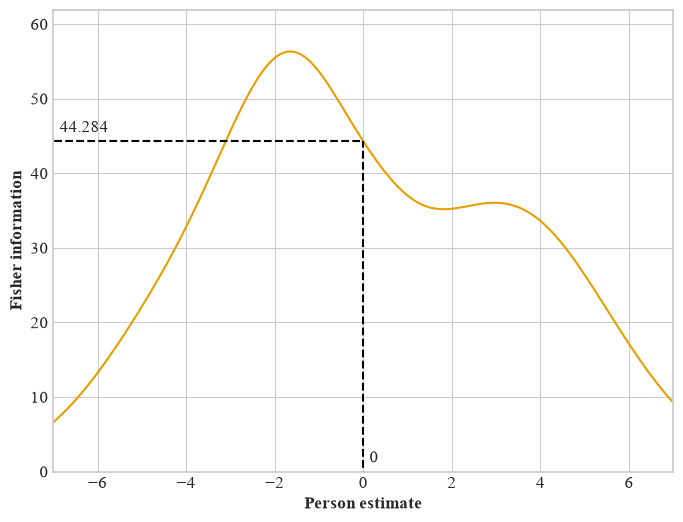

In [43]:
mfrm.test_info_pseudo_halo(point_info_lines=[0], point_info_labels=True,
                           xmin=-7, xmax=7, filename='my_mfrm_pseudo_halo_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

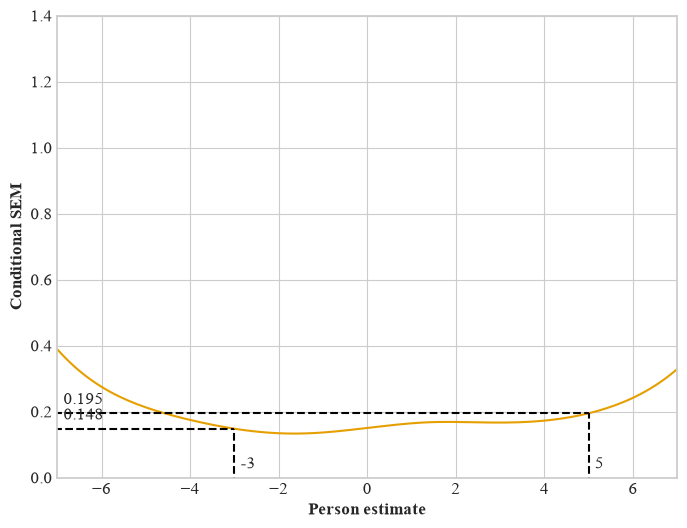

In [44]:
mfrm.test_csem_pseudo_halo(point_csem_lines=[-3, 5], point_csem_labels=True,
                           ymax=1.4, xmin=-7, xmax=7, filename='my_mfrm_pseudo_halo_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

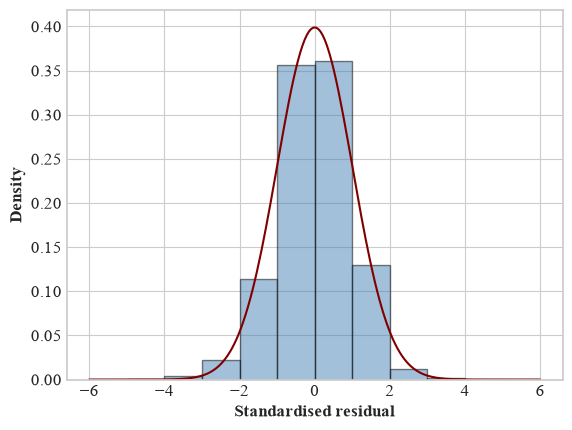

In [45]:
mfrm.std_residuals_plot_pseudo_halo(bin_width=0.6, normal=True, filename='my_mfrm_pseudo_halo_std_residuals_plot')

**Model selection.** Since `pseudo_halo` is nested between `global` and `items`, `model_selection()` can compare it against all eight MFRM rater representations (or a chosen subset via `models=`) directly via AIC, BIC, or LR. See the `Model selection` example notebook for a full worked demonstration, including this exact comparison (`models=['items', 'pseudo_halo']`) run on a `pseudo_halo`-generated data set.

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [46]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_pseudo_halo_anchor(anchors)

CPU times: user 15.2 ms, sys: 2.36 ms, total: 17.5 ms
Wall time: 15.5 ms


Check the anchored item locations against the unanchored ones.

In [47]:
item_check = pd.DataFrame({'Unanchored': mfrm.items,
                           'Anchored': mfrm.anchor_items_pseudo_halo})
round(item_check, 3)

,Unanchored,Anchored
Item_1,0.946,0.886
Item_2,0.276,0.255
Item_3,-0.413,-0.396
Item_4,0.726,0.772
Item_5,0.863,0.896
Item_6,-0.199,-0.250
Item_7,-0.170,-0.277
Item_8,-1.031,-0.976
Item_9,-0.829,-0.806
Item_10,-0.168,-0.216


Check the anchored rater x item severities against the unanchored ones (two separate dataframes)

In [48]:
round(mfrm.raters_pseudo_halo, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater_1,1.029,0.728,0.418,0.930,0.991,0.515,0.527,0.141,0.232,0.528,0.198,1.008
Rater_2,-1.367,-1.042,-0.708,-1.260,-1.326,-0.812,-0.825,-0.408,-0.506,-0.827,-0.470,-1.345
Rater_3,0.494,0.452,0.409,0.480,0.489,0.422,0.424,0.370,0.383,0.424,0.378,0.491
Rater_4,0.680,0.631,0.581,0.664,0.674,0.596,0.598,0.536,0.551,0.599,0.545,0.676
Rater_5,-0.805,-0.865,-0.927,-0.825,-0.812,-0.908,-0.905,-0.983,-0.965,-0.905,-0.971,-0.809
Rater_6,1.125,1.016,0.905,1.089,1.111,0.940,0.944,0.806,0.838,0.945,0.826,1.117
Rater_7,-1.061,-1.037,-1.013,-1.053,-1.058,-1.021,-1.022,-0.992,-0.999,-1.022,-0.996,-1.059
Rater_8,-0.061,0.126,0.318,0.001,-0.037,0.258,0.250,0.490,0.434,0.250,0.454,-0.048


In [49]:
round(mfrm.anchor_raters_pseudo_halo, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater_1,0.795,0.531,0.258,0.747,0.799,0.319,0.308,0.015,0.087,0.333,0.039,0.856
Rater_2,-1.540,-1.227,-0.904,-1.484,-1.545,-0.976,-0.963,-0.616,-0.700,-0.993,-0.643,-1.613
Rater_3,0.283,0.264,0.244,0.279,0.283,0.248,0.247,0.226,0.231,0.249,0.228,0.287
Rater_4,0.488,0.448,0.407,0.481,0.489,0.417,0.415,0.371,0.382,0.419,0.375,0.497
Rater_5,-1.038,-1.062,-1.086,-1.042,-1.037,-1.081,-1.082,-1.109,-1.102,-1.080,-1.106,-1.032
Rater_6,0.919,0.823,0.724,0.902,0.921,0.746,0.742,0.636,0.662,0.752,0.645,0.942
Rater_7,-1.273,-1.231,-1.188,-1.265,-1.273,-1.198,-1.196,-1.150,-1.162,-1.200,-1.154,-1.282
Rater_8,-0.238,-0.049,0.146,-0.204,-0.241,0.102,0.110,0.319,0.268,0.092,0.303,-0.282


Produce a Wright map (unanchored), showing the person location distribution alongside an item strip and a rater panel (severity shift, lambda), plus a stretch panel showing each rater's item-difficulty stretch multiplier (omega), with mean/±1SD/±2SD reference marks for persons

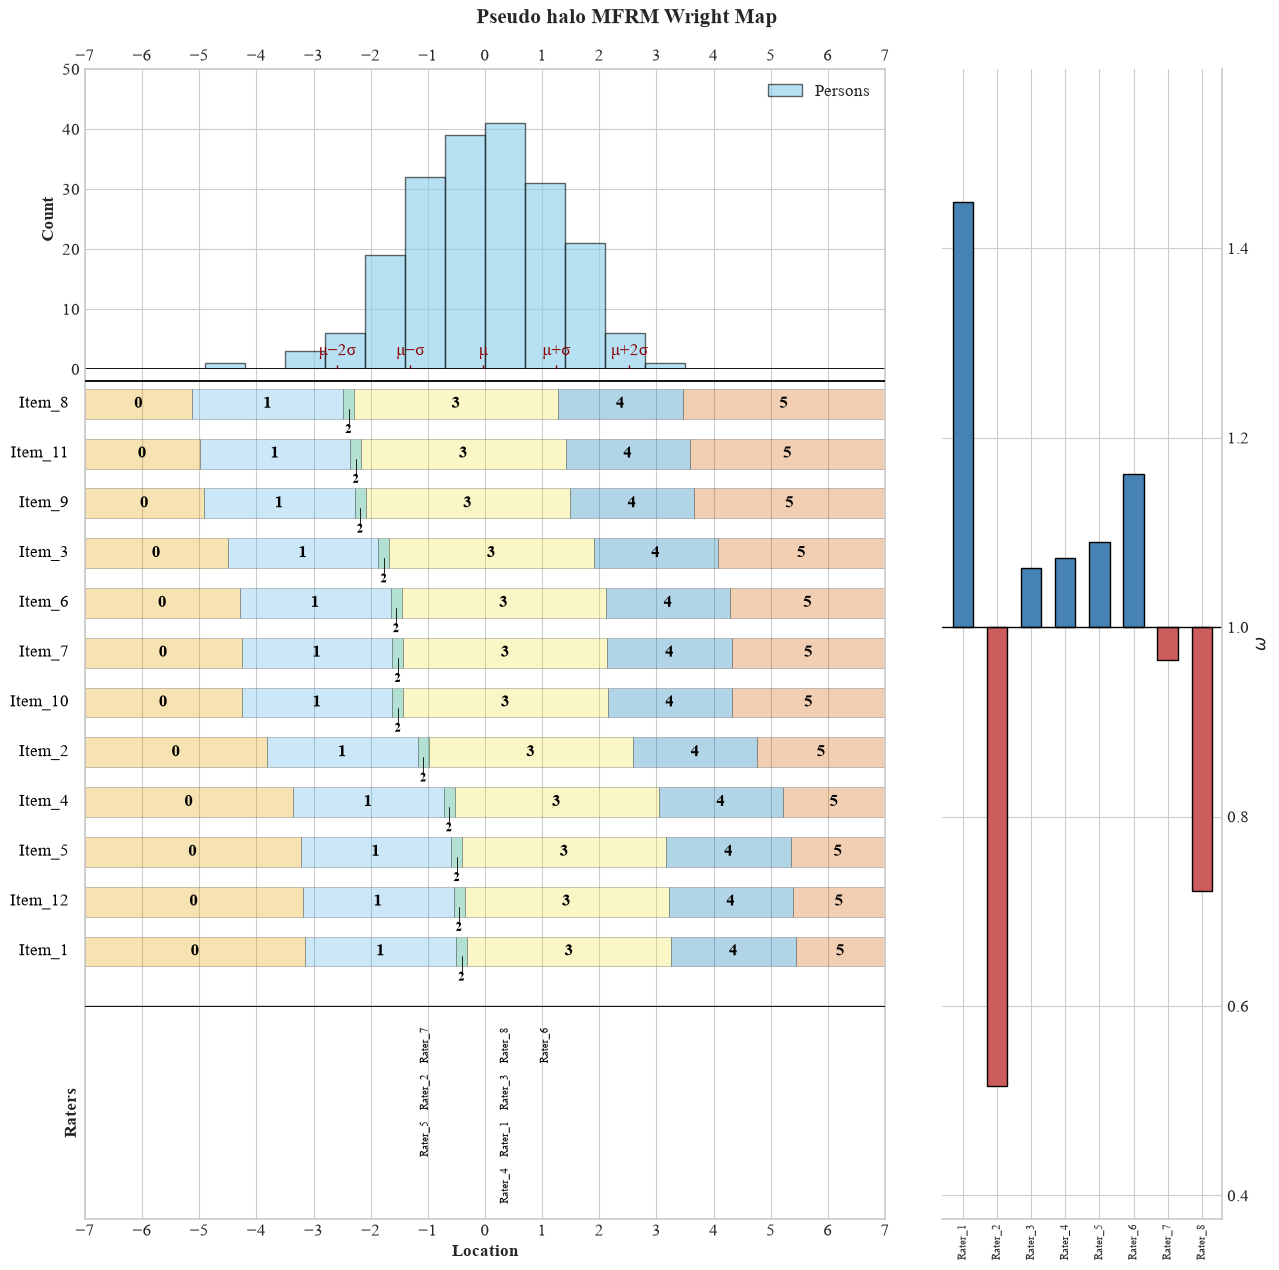

In [50]:
mfrm.wright_map_pseudo_halo(item_strip=True, facet_labels=True, show_stretch=True, distribution_markers=True, title='Pseudo halo MFRM Wright Map', filename='my_mfrm_pseudo_halo_wright_map')